In [ ]:
#导入相关库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import seaborn as sns
n = 400 #样本量的设置,生成样本量为n
n1 = 200
from pandas import read_csv
import math

import random
import csv

import numpy as np
import pandas as pd
from numpy import mat

from sklearn.svm import SVC
import statsmodels.api as sm
import pylab as pl
import scipy.linalg as sl
def I_13(x):
    if x >= 1:
        return 1
    else:
        return 0

def I_12(x):
    if (x >-1) & (x<1):
        return 1
    else:
        return 0
    
def I_11(x):
    if (x <= -1):
        return 1
    else:
        return 0

def I_23(x):
    if x >= 1.5:
        return 1
    else:
        return 0

def I_22(x):
    if (x >-0.5) & (x<1.5):
        return 1
    else:
        return 0
    
def I_21(x):
    if (x <= -0.5):
        return 1
    else:
        return 0

def I_21or(x):
    if x < -0.5:
        return 1
    else:
        return 0

def I_22or(x):
    if (x >-0.5) & (x<1.5):
        return 1
    else:
        return 0
    
def I_23or(x):
    if (x > 1.5):
        return 1
    else:
        return 0

def I_13or(x):
    if x >= 1:
        return 1
    else:
        return 0

def I_12or(x):
    if (x >-1) & (x<1):
        return 1
    else:
        return 0
    
def I_11or(x):
    if (x <= -1):
        return 1
    else:
        return 0 
def ST(b, lam):
    st = np.sign(b) * max(abs(b) - lam, 0)
    return st
def MCP(a,b,gamma,rho,lam):
    if abs(a)<= gamma*rho*b:
        return ST(a,b)/(1-1/(gamma*lam/b))
    else:
        return a
from scipy.special import comb
def rand_index_score(clusters, classes):
    tp_plus_fp = comb(np.bincount(clusters), 2).sum()
    tp_plus_fn = comb(np.bincount(classes), 2).sum()
    A = np.c_[(clusters, classes)]
    tp = sum(comb(np.bincount(A[A[:, 0] == i, 1]), 2).sum()
             for i in set(clusters))
    fp = tp_plus_fp - tp
    fn = tp_plus_fn - tp
    tn = comb(len(A), 2) - tp - fp - fn
    return (tp + tn) / (tp + fp + fn + tn)


import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

In [ ]:
#重复循环50次试一下
np.random.seed(1809)
Deviation_0 = []
Deviation_1 = []
Deviation_2 = []

Deviation1_1 = []
Deviation1_2 = []
Deviation1_3 = []
Deviation2_1 = []
Deviation2_2 = []
Deviation2_3 = []
beta0_all = []
beta1_all = []
beta2_all = []
alpha1_1all =[]
alpha1_2all =[]
alpha1_3all =[]
alpha2_1all = []
alpha2_2all = []
alpha2_3all =[]
ACC1 = []
ACC2 = []
ACC_final = []
ACC_pre = []
K1 = []
K2 =  []
RI1 = []
RI2 = []
ACCp2 = []
ACCp1 = []
ACCp_final = []
lst1 = []
lst2 = []
beta0_allor = []
beta1_allor = []
beta2_allor = []
beta3_allor = []
alpha1_1allor = []
alpha1_3allor = []
alpha1_2allor = []
alpha2_1allor = []
alpha2_2allor = []
alpha2_3allor = []
Pre1 = []
Pre2 = []
for i in range(200):
    print(i)
    beta_0 = 1
    beta_1 = 1
    beta_2 = 1

    # 随机生成X1 X2
    X0 = np.ones(n)
    mean1 = (0, 0)
    cov1 = np.array([[1, 0.3], [0.3, 1]])
    X = np.random.multivariate_normal(mean1, cov1, (n,))
    X = X.T
    X1 = X[0]
    X2 = X[1]
 
    Z1 = np.random.normal(loc=1,scale=1,size=n)
    Z2 = np.random.normal(loc=2,scale=1,size=n)

    random_u1 =  np.random.uniform(low=0.0, high=1.0, size = n)
    random_u2 =  np.random.uniform(low=0.0, high=1.0, size = n)
    def alpha11(x1,x2):
        if (x1 + 0.5*x2 -0.5 < 0):
            return -2
        elif (x1 + 0.5*x2 - 0.5 > 0) & (x1 - x2  < 0):
            return 0
        else:
            return 2
    #生成变系数beta1(x)数据
    alpha1 = []
    for i in range(n):
        alpha1_1 = alpha11(random_u1[i],random_u2[i])
        alpha1.append(alpha1_1)

    def alpha22(w1,w2):
        if (w1 + 2* w2 - 1 < 0):
            return -1.5
        elif (w1 - w2  < 0) & (w1 + 2* w2 - 1 > 0):
            return 0.5
        else:
            return 2.5

    alpha2 = []
    for i in range(n):
        alpha2_1 = alpha22(random_u1[i],random_u2[i])
        alpha2.append(alpha2_1) 

    epli =np.random.normal(loc=0,scale=0.5,size=n)#从正态（高斯）分布中抽取随机样本。
    #获取Y
    def func(X0,X1,X2,Z1,Z2):
        Y = A * X0 + B* X1 + C * X2  + E*Z1 + F* Z2 + eplison
        return Y
    Y1 = []
    for i in range(n):#生成数据的长度
        A = beta_0
        B = beta_1
        C  = beta_2
   
        E = alpha1[i]
        F = alpha2[i]
        eplison = epli[i]
        X0_0 = X0[i]
        X1_1 = X1[i]
        X2_1 = X2[i]

        Z1_1 = Z1[i]
        Z2_1 = Z2[i]
        Y1_1 = func(X0_0,X1_1,X2_1,Z1_1,Z2_1)
        Y1.append(Y1_1)

    #生成一列索引
    index = []
    for i in range(n):
        index_1 = i
        index.append(int(index_1))

    data_arry = []
    data_arry.append(index)
    data_arry.append(Y1)
    data_arry.append(X0)
    data_arry.append(X1)
    data_arry.append(X2)
    data_arry.append(Z1)
    data_arry.append(Z2)

    data_arry.append(random_u1)
    data_arry.append(random_u2)
    data_arry.append(alpha1)
    data_arry.append(alpha2)
    np_data = np.array(data_arry)
    np_data = np_data.T
    np_data = np.array(np_data)
    save = pd.DataFrame(np_data,columns = ['index','Y1','X0','X1','X2', 'Z1', 'Z2','U1','U2','alpha1','alpha2']) 
    save.to_csv('ZGDP 44 first1.csv',index=False,header=True) 
    #随机生成要预测的数据
    randompre_u1 = np.random.uniform(low=0.0, high=1.0, size = n1)
    randompre_u2 = np.random.uniform(low=0.0, high=1.0, size = n1)
    #生成变系数beta1(x)数据
    alpha1p = []
    for i in range(n1):
        alpha1_1 = alpha11(randompre_u1[i],randompre_u2[i])
        alpha1p.append(alpha1_1)
    alpha2p = []
    for i in range(n1):
        alpha2_2 = alpha22(randompre_u1[i],randompre_u2[i])
        alpha2p.append(alpha2_2)
    # 随机生成X1 X2
    X0 = np.ones(n1)
    mean1 = (0,0)
    cov1 = np.array([[1,0.3],[0.3,1]])
    X = np.random.multivariate_normal(mean1, cov1, (n1,))
    X = X.T
    X1 = X[0]
    X2 = X[1]
    # 随机生成Z1 Z2
    Z1 = np.random.normal(loc=1,scale=1,size=n1)
    Z2 = np.random.normal(loc=2,scale=1,size=n1)
    
  
    # 随机生成服从正态分布的噪声
    eplip =np.random.normal(loc=0,scale=0.5,size=n1)#从正态（高斯）分布中抽取随机样本。
    Yp = []
    for i in range(n1):#生成数据的长度
        A = beta_0
        B = beta_1
        C  = beta_2
        E = alpha1p[i]
        F = alpha2p[i]
        eplison = epli[i]
        X0_0 = X0[i]
        X1_1 = X1[i]
        X2_1 = X2[i]

        Z1_1 = Z1[i]
        Z2_1 = Z2[i]
        Y1_1 = func(X0_0,X1_1,X2_1,Z1_1,Z2_1)
        Yp.append(Y1_1)
    #生成一列索引
    indexp = []
    for i in range(n1):
        index_1 = i
        indexp.append(int(index_1))
    data_arrypre = []
    data_arrypre.append(indexp)
    data_arrypre.append(Yp)
    data_arrypre.append(X0)
    data_arrypre.append(X1)
    data_arrypre.append(X2)
    data_arrypre.append(Z1)
    data_arrypre.append(Z2)
    data_arrypre.append(randompre_u1)
    data_arrypre.append(randompre_u2)
    data_arrypre.append(alpha1p)
    data_arrypre.append(alpha2p)
    np_datapre = np.array(data_arrypre)
    np_datapre = np_datapre.T
    np_datapre = np.array(np_datapre)
    savepre = pd.DataFrame(np_datapre,columns = ['index','Y1','X0','X1','X2', 'Z1', 'Z2','U1','U2','alpha1','alpha2']) 
    savepre.to_csv('ZGDP 4.4 first pre.csv',index=False,header=True) 
    filenamepre = 'ZGDP 4.4 first pre.csv'
    datapre = read_csv(filenamepre)

    #生成判罚阵
    # 导入随机生成的数据
    filename = 'ZGDP 44 first1.csv'
    data = read_csv(filename)

    with open('ZGDP 44 first1.csv','r')as file:#'r'为读取文本
        reader = csv.DictReader(file)
        datas = [row for row in reader]

    def distance(d1, d2):
        """2范数，即欧几里得距离
           1范数，曼哈顿距离"""
        res = 0
        for key in("U1","U2"):
            #res+=abs((float(d1[key])-float(d2[key])))#一范数
            res+=(float(d1[key])-float(d2[key]))**2  #二范数
        return res
    #定义距离函数
    #影响knn的一般为距离的定义和k的取值，所以我把距离函数单独定义一下，这样方便更换

    #KNN计算离点最近的K-1个点，这是因为此时我在计算距离时并没有把自身排除，在排序时总有它自身距离自身为0的一个点
    K = 5  #以2-NN为例
    def KNN(data):
        #1.距离
        res = [
            {"index": train['index'],"distance": distance(data,train)}
            #diatance(data,train)
            for train in datas
        ]
        #2升序排列
        res = sorted(res , key = lambda item:item["distance"])
         #3.取前K个
        res2 = res[0:K]
        r2 = []
        for r in res2:
            r_1 = r["index"]
            r2.append(r_1)
        #print(res2)
        #print(r2)
        return r2
    k = 4#与前面的K-1相等
    G = np.zeros(shape=(n*k,n))#nk*n维矩阵
    #G  生成nk*n的零矩阵

    for i in range(0,n):
        for m in range(0,k):
            G[m+k*i][i] =  1
            ##k行一个元素为1 
    #G

    for j in range(0,n):
        list1 = KNN(datas[j])
        list2 = list1[1:]#取最近的K-1 = k个值
        for i in range(0,k):
            r_12 = int(float(list2[i]))
            G[i+j*k][r_12] = -1
            #G[i+j][#knn的那几个元素] = -1 
    #生成所需要的G矩阵
    #给初值
    lam = 0.001
    m = 2
    I_p = np.diag(np.ones(m))
    A = np.kron(G,I_p)
    X = (np.array([data['X0'].values,data['X1'].values,data['X2'].values])).T
    Z = np.array([data['Z1'].values,data['Z2'].values]).T
    Z_1 = np.diag(data['Z1'].values)
    Z_2 = np.diag(data['Z2'].values)
    Y_1 = data['Y1'].values
    I_n = np.diag(np.ones(n))
    Q_1 = np.dot(X,np.linalg.pinv(np.dot(X.T,X)))
    Q_X = I_n - np.dot(Q_1,X.T)

    Z00 = []
    for i in range(n):
        Z00 = sl.block_diag(Z00,Z[i])
        i = i+1
    Z00 = np.delete(Z00, 0, 0) #块对角化.Z = (Z_1^T,...,Z_n^T)

    alpha_intial = np.dot(np.linalg.pinv(np.dot(np.dot(Z00.T,Q_X),Z00)+lam* np.dot(A.T,A)),np.dot(np.dot(Z00.T,Q_X),Y_1))
    beta_intial = np.dot(np.dot(np.linalg.pinv(np.dot(X.T,X)),X.T),Y_1 - np.dot(Z00,alpha_intial))

    alpha11 = []
    alpha22 = []
    for i in range(n):
        alpha_11 = alpha_intial[2*i]
        alpha_22 = alpha_intial[2*i+1]
        alpha11.append(alpha_11)
        alpha22.append(alpha_22)
    alpha11 = np.array(alpha11)
    alpha22 = np.array(alpha22)
    alpha1_before  = data['alpha1'].values
    alpha2_before  = data['alpha2'].values
    beta = beta_intial  
    lam = 0.5
    rho = 1
    gamma  = 2
    alpha1 = alpha11
    alpha2 = alpha22

    alpha1_old = alpha1
    alpha2_old = alpha2
    delta1 = np.dot(G,alpha1)
    delta2 = np.dot(G,alpha2)
    mu1 = np.ones(4*n) - 1
    mu2 = np.ones(4*n) - 1
    epsilon = 1e-4
    k=0
    F1=[]
    F2 = []
    F3 = []
    #每步计算结果
    while k < 50:#迭代
        alpha1 = np.dot(np.linalg.pinv(np.dot(np.dot(Z_1.T,Q_X),Z_1) +rho* np.dot(G.T,G)),
                        (np.dot(np.dot(Z_1.T,Q_X),(Y_1 - np.dot(Z_2,alpha2))) + rho * np.dot(G.T,delta1 - 1/rho*mu1)))
        alpha2 = np.dot(np.linalg.pinv(np.dot(np.dot(Z_2.T,Q_X),Z_2) + rho* np.dot(G.T,G)),
                        (np.dot(np.dot(Z_2.T,Q_X),(Y_1 - np.dot(Z_1,alpha1))) + rho * np.dot(G.T,delta2 - 1/rho*mu2)))
        beta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T,X)),X.T),Y_1 - np.dot(Z_1,alpha1)-np.dot(Z_1,alpha2)) 

        ras1 = []
        bb1 = np.dot(G,alpha1)+1/rho*mu1
        for i in range(4*n):
            b  = bb1[i]
            res1 = MCP(b,lam/rho,gamma,rho,lam)
            ras1.append(res1)
        delta1 = np.asarray(ras1)
        ras2 = []
        bb2 = np.dot(G,alpha2)+1/rho*mu2
        for i in range(4*n):
            b  = bb2[i]
            res2 = MCP(b,lam/rho,gamma,rho,lam)
            ras2.append(res2)
        delta2 = np.asarray(ras2)
        mu1 = mu1 + rho*(np.dot(G,alpha1) - delta1)
        mu2 = mu2 + rho*(np.dot(G,alpha2) - delta2)
        k = k+1

        #停止迭代的条件 
        F1.append(beta)
        if np.linalg.norm(mu1)/(n*4) < epsilon and np.linalg.norm(mu2)/(4*n) < epsilon:
                break
        else:
            alpha1_old = alpha1 
            alpha2_old = alpha2
            #迭代过程 
    #预测组数K1，K2
    alpha1_sort = np.sort(alpha1)
    lst1.append(alpha1)
    lst2.append(alpha2)
    biandian1 = np.diff(alpha1_sort)
    location_1 = np.array(np.where(abs(biandian1) > 0.5))
    location_1 = np.insert(location_1, 0, 0)  # 在0号位置插入元素0
    location_1 = np.insert(location_1, len(location_1), 398)  # 在数组末尾插入元素
    #location_11 = np.where(np.diff(location_1)> 0.05*800)
    K_1 = np.count_nonzero(np.diff(location_1)> 0.05*n)
    K1.append(K_1)
    alpha2_sort = np.sort(alpha2)
    biandian2 = np.diff(alpha2_sort)
    location_2 = np.array(np.where(abs(biandian2) > 0.5))
    location_2 = np.insert(location_2, 0, 0)  # 在0号位置插入元素0
    location_2 = np.insert(location_2, len(location_2), 398)  # 在数组末尾插入元素
    K_2 = np.count_nonzero(np.diff(location_2)> 0.05*n)
    K2.append(K_2)
    #计算RI
    #把数据整合一下
    filename = 'ZGDP 44 first1.csv'
    data = read_csv(filename)    
    result_array = []
    index_1 = data['index'].values
    Y1 = data['Y1'].values
    Z1 = data['Z1'].values
    Z2 = data['Z2'].values
    X0 = data['X0'].values
    X1 = data['X1'].values
    X2 = data['X2'].values
    result_array.append(index_1)
    result_array.append(Y1)
    result_array.append(Z1)
    result_array.append(Z2)
    result_array.append(X0)
    result_array.append(X1)
    result_array.append(X2)

    result_array.append(random_u1)
    result_array.append(random_u2)
    result_array.append(alpha1_before)
    result_array.append(alpha2_before)
    alpha1_unsort = np.squeeze(np.array(alpha1))
    result_array.append(alpha1_unsort)
    alpha2_unsort = np.squeeze(np.array(alpha2))
    result_array.append(alpha2_unsort)
    result_data = np.array(result_array)
    result_data = result_data.T
    result = pd.DataFrame(result_data, columns = ['index','Y','Z1','Z2','X0','X1','X2','U1','U2','alpha1_origin','alpha2_origin','alpha1','alpha2'])   
    result.sort_values(by="alpha1" , inplace=True, ascending=True)
    result['new_label1diff']=abs(result['alpha1'].diff(-1).shift())#做alpha1差分,添加列
    result = result.fillna(0)#nan替换为0
    result.reset_index(drop=True, inplace=True)#行号变回来，为了便于根据差分赋值
    dfsuoyin1 = result.loc[result['new_label1diff'] > 0.6] #提取变点的位置
    biandianxu1 = dfsuoyin1.index.values
    biandianxu1 = np.insert(biandianxu1, 0, 0, axis=None)
    biandianxu1 = np.insert(biandianxu1, len(biandianxu1),n, axis=None)
    labels_pred1 = np.zeros(n,int)
    for i in range(len(biandianxu1)-1):
        labels_pred1[biandianxu1[i]:biandianxu1[i+1]] = i
    labels_pred1[biandianxu1[len(biandianxu1)-1]:n] = len(biandianxu1)#给出预测的分组结果
    result['labels1_true'] = result.alpha1_origin.apply(lambda x: 1 if x == 2  else (2 if x == 0 else 3))
    labels1_true = result['labels1_true'].values
    RI1_1 = rand_index_score (labels1_true, labels_pred1)
    RI1.append(RI1_1)
    result.sort_values(by="alpha2" , inplace=True, ascending=True)
    result['new_label2diff']=abs(result['alpha2'].diff(-1).shift())#做alpha2差分,添加列
    result = result.fillna(0)#nan替换为0
    result.reset_index(drop=True, inplace=True)#行号变回来，为了便于根据差分赋值
    dfsuoyin2 = result.loc[result['new_label2diff'] > 0.6] 
    biandianxu2 = dfsuoyin2.index.values
    biandianxu2 = np.insert(biandianxu2, 0, 0, axis=None)
    biandianxu2 = np.insert(biandianxu2, len(biandianxu2),n, axis=None)
    labels_pred2 = np.zeros(n,int)
    for i in range(len(biandianxu2)-1):
        labels_pred2[biandianxu2[i]:biandianxu2[i+1]] = i
    labels_pred2[biandianxu2[len(biandianxu2)-1]:n] = len(biandianxu2)#根据变点和其索引赋值分组标签

    result['labels2_true'] = result.alpha2_origin.apply(lambda x: 1 if x == -1.5  else (2 if x == 0.5 else 3))
    labels2_true = result['labels2_true'].values
    RI2_1 = rand_index_score (labels2_true, labels_pred2)
    RI2.append(RI2_1)
    #做分类 
    label1= []
    for i in range(n):
        if result.alpha1[i]>1:
            label1_1 = 2
        elif result.alpha1[i]<-1:
            label1_1 = -2
        else:
            label1_1 = 0
        label1.append(label1_1)
    label1 = np.array(label1)
    clf1 = SVC(kernel='linear',C=10)  
    Z_ob = result[['U1','U2']]
    clf1.fit(X=Z_ob,y=label1)
    accsvc1 = clf1.score(X=Z_ob,y=label1)#得分
    accp1 = clf1.predict(X=Z_ob) 
    acc1 = 1-np.count_nonzero((accp1 - label1))/len(accp1)
    ACC1.append(acc1)
    #做预测
    pre1 = clf1.predict(datapre[['U1','U2']])
    acc_pre1 = 1-np.count_nonzero((pre1 - datapre.alpha1))/len(pre1)
    ACCp1.append(acc_pre1)
    x_min,x_max = 0,1#取横坐标的取值范围
    y_min,y_max = 0,1#取纵坐标的取值范围
    xx,yy = np.meshgrid(np.arange(x_min,x_max,0.01),np.arange(y_min,y_max,0.01))#生成网格点
    Z = clf1.predict(np.c_[xx.ravel(),yy.ravel()])#用我们的模型预测出来的网格点中的所有的值
    Pre1.append(Z)
    label2= []
    for i in range(n):
        if result.alpha2[i] < -0.5:
            label2_1 = -2
        elif result.alpha2[i]> 1.5:
            label2_1 = 2
        else:
            label2_1 = 0
        label2.append(label2_1)
    label2 = np.array(label2)  
    Z_ob = result[['U1','U2']]
    clf2 = SVC(kernel='linear',C=10)
    clf2.fit(X=Z_ob,y=label2)
    accsvc2 = clf2.score(X=Z_ob,y=label2)#得分
    accp2 = clf2.predict(X=Z_ob)
    label2_result = []
    for i in range(n):
        if result.alpha2_origin[i] == -1.5:
            label2_result1 = -2
        elif result.alpha2_origin[i] == 2.5:
            label2_result1 = 2
        else:
            label2_result1 = 0
        label2_result.append(label2_result1)
    label2_result = np.array(label2_result)
    acc2 = 1-np.count_nonzero((accp2 - label2_result))/len(accp2)
    ACC2.append(acc2)
    #做预测
    pre2_datapre = []
    for i in range(n1):
        if datapre.alpha2[i] == -1.5:
            pre2_datapre1 = -2
        elif datapre.alpha2[i] == 2.5:
            pre2_datapre1 = 2
        else:
            pre2_datapre1 = 0
        pre2_datapre.append(pre2_datapre1)
    pre2_datapre = np.array(pre2_datapre)
    pre2 = clf2.predict(datapre[['U1','U2']])
    acc_pre2 = 1-np.count_nonzero((pre2 - pre2_datapre))/len(pre2)
    ACCp2.append(acc_pre2)
    Z2 = clf2.predict(np.c_[xx.ravel(),yy.ravel()])
    Pre2.append(Z2)
    #计算准确率
    acc_origin = []
    acc_origin.append(accp1 - label1)
    acc_origin.append(accp2 - label2_result)
    acc_origin = np.array(acc_origin)
    #训练集的总正确率
    acc1_final = np.array(np.linalg.norm(x=acc_origin.T, ord=1, axis=1, keepdims=False))
    acc_final = np.sum(acc1_final==0)/len(acc1_final)
    ACC_final.append(acc_final)
    #测试集的准确率
    acc_pre = []
    acc_pre.append(pre1 - datapre.alpha1)
    acc_pre.append(pre2 - pre2_datapre)
    acc_pre = np.array(acc_pre)
    acc2_final = np.array(np.linalg.norm(x=acc_pre.T, ord=1, axis=1, keepdims=False))
    acc_prefinal = np.sum(acc2_final==0)/len(acc2_final)
    ACC_pre.append(acc_prefinal)
 
    z1 = np.array(result.Z1)
    z2 = np.array(result.Z2)
    I11_or = []
    #for i in range(n):
    for i in  result.alpha1_origin:
    #for i in alpha1_result:
        I1_1or = I_11or(i)
        I11_or.append(I1_1or)

    I12_or = []
    for i in  result.alpha1_origin:
    #for i in alpha1_result:
    #for i in range(n):
        I1_2or = I_12or(i)
        I12_or.append(I1_2or)
    I13_or = []
    for i in result.alpha1_origin:
    #for i in alpha1_result:
    #for i in range(n):
        I1_3or = I_13or(i)
        I13_or.append(I1_3or)
    I21_or = []
    for i in  result.alpha2_origin:
    #for i in alpha2_result:
    #for i in range(n):
        I2_1or = I_21or(i)
        I21_or.append(I2_1or)

    I22_or = []
    #for i in alpha2_result:
    #for i in range(n):
    for i in  result.alpha2_origin:
        I2_2or = I_22or(i)
        I22_or.append(I2_2or)
        
    I23_or = []
    for i in  result.alpha2_origin:
    #for i in alpha2_result:
    #for i in range(n):
        I2_3or = I_23or(i)
        I23_or.append(I2_3or)
    
    zI_111or = z1*I11_or
    zI_112or = z1*I12_or
    zI_113or = z1*I13_or
    zI_221or = z2*I21_or
    zI_222or = z2*I22_or
    zI_223or = z2*I23_or
    
    data_modelor = []
    Y1 = result['Y'].values
    X0 = result['X0'].values
    X1 = result['X1'].values
    X2 = result['X2'].values
    data_modelor.append(Y1)
    data_modelor.append(X0)
    data_modelor.append(X1)
    data_modelor.append(X2)

    data_modelor.append(zI_111or)
    data_modelor.append(zI_112or)
    data_modelor.append(zI_113or)
    data_modelor.append(zI_221or)
    data_modelor.append(zI_222or)
    data_modelor.append(zI_223or)
    data_modelor = np.array(data_modelor)
    data_modelor = data_modelor.T
    data_modelor = pd.DataFrame(data_modelor, columns = ['Y','X0','X1','X2','z1*I11or','z1*I12or','z1*I13or','z2*I21or','z2*I22or','z2*I23or']) 
    train_colsor = data_modelor.columns[1:]
    linearor = sm.OLS(data_modelor['Y'],data_modelor[train_colsor])
    result_for = linearor.fit()
    beta0_or = result_for.params.iloc[0]
    beta1_or= result_for.params.iloc[1]
    beta2_or = result_for.params.iloc[2]

    alpha1_1or = result_for.params.iloc[3]
    alpha1_2or = result_for.params.iloc[4]
    alpha1_3or = result_for.params.iloc[5]
    alpha2_1or = result_for.params.iloc[6]
    alpha2_2or = result_for.params.iloc[7]
    alpha2_3or = result_for.params.iloc[8]
    beta0_alor = beta0_or
    beta1_alor = beta1_or
    beta2_alor = beta2_or
    alpha1_1alor = alpha1_1or
    alpha1_2alor = alpha1_2or
    alpha1_3alor = alpha1_3or
    alpha2_1alor = alpha2_1or
    alpha2_2alor = alpha2_2or
    alpha2_3alor = alpha2_3or
    beta0_allor.append(beta0_alor)
    beta1_allor.append(beta1_alor)
    beta2_allor.append(beta2_alor)
    alpha1_1allor.append(alpha1_1alor)
    alpha1_2allor.append(alpha1_2alor)
    alpha1_3allor.append(alpha1_3alor)
    alpha2_1allor.append(alpha2_1alor)
    alpha2_2allor.append(alpha2_2alor)
    alpha2_3allor.append(alpha2_3alor)
    #knn fused penalty function 下的分组结果作回归
    I11 = []
    #for i in range(n):
    for i in label1:
    #for i in alpha1_result:
        I1_1 = I_11(i)
        I11.append(I1_1)

    I12 = []
    for i in label1:
    #for i in alpha1_result:
    #for i in range(n):
        I1_2 = I_12(i)
        I12.append(I1_2)


    I13 = []
    for i in label1:
    #for i in alpha1_result:
    #for i in range(n):
        I1_3 = I_13(i)
        I13.append(I1_3)


    I21 = []
    for i in label2:
    #for i in alpha2_result:
    #for i in range(n):
        I2_1 = I_21(i)
        I21.append(I2_1)

    I22 = []
    #for i in alpha2_result:
    #for i in range(n):
    for i in label2:
        I2_2 = I_22(i)
        I22.append(I2_2)
        
    I23 = []
    for i in label2:
    #for i in alpha2_result:
    #for i in range(n):
        I2_3 = I_23(i)
        I23.append(I2_3)
    
    zI_111 = z1*I11
    zI_112 = z1*I12
    zI_113 = z1*I13
    zI_221 = z2*I21
    zI_222 = z2*I22
    zI_223 = z2*I23
    
    data_model = []
    Y1 = result['Y'].values
    X0 = result['X0'].values
    X1 = result['X1'].values
    X2 = result['X2'].values

    data_model.append(Y1)
    data_model.append(X0)
    data_model.append(X1)
    data_model.append(X2)

    data_model.append(zI_111)
    data_model.append(zI_112)
    data_model.append(zI_113)
    data_model.append(zI_221)
    data_model.append(zI_222)
    data_model.append(zI_223)
    data_model = np.array(data_model)
    data_model = data_model.T
    data_model = pd.DataFrame(data_model, columns = ['Y','X0','X1','X2','z1*I11','z1*I12','z1*I13','z2*I21','z2*I22','z2*I23']) 
    train_cols = data_model.columns[1:]
    linear = sm.OLS(data_model['Y'],data_model[train_cols])
    result_f = linear.fit()
    result_f.summary()
    beta0_old = 1
    beta1_old = 1
    beta2_old = 1

    alpha1_1_old = -2
    alpha1_2_old = 0
    alpha1_3_old = 2

    alpha2_3_old = 2.5
    alpha2_2_old = 0.5
    alpha2_1_old = -1.5
    
    beta0 = result_f.params.iloc[0]
    beta1= result_f.params.iloc[1]
    beta2 = result_f.params.iloc[2]
    alpha1_1 = result_f.params.iloc[3]
    alpha1_2 = result_f.params.iloc[4]
    alpha1_3 = result_f.params.iloc[5]
    alpha2_1 = result_f.params.iloc[6]
    alpha2_2 = result_f.params.iloc[7]
    alpha2_3 = result_f.params.iloc[8]
    #求偏差
    deviation_0 = beta0-beta0_old
    deviation_1 = beta1-beta1_old
    deviation_2 = beta2-beta2_old

    deviation1_1 = (alpha1_1-alpha1_1_old)
    deviation1_2 = (alpha1_2-alpha1_2_old)
    deviation1_3 = (alpha1_3-alpha1_3_old)
    deviation2_1 = (alpha2_1-alpha2_1_old)
    deviation2_2 = (alpha2_2-alpha2_2_old)
    deviation2_3 = (alpha2_3-alpha2_3_old)
    
    beta0_al = beta0
    beta1_al = beta1
    beta2_al = beta2
    alpha1_1al = alpha1_1
    alpha1_2al = alpha1_2
    alpha1_3al = alpha1_3
    alpha2_1al = alpha2_1
    alpha2_2al = alpha2_2
    alpha2_3al = alpha2_3
    
    Deviation_0.append(deviation_0)
    Deviation_1.append(deviation_1)
    Deviation_2.append(deviation_2)
    Deviation1_1.append(deviation1_1)
    Deviation1_2.append(deviation1_2)
    Deviation1_3.append(deviation1_3)
    Deviation2_1.append(deviation2_1)
    Deviation2_2.append(deviation2_2)
    Deviation2_3.append(deviation2_3)
    beta0_all.append(beta0_al)
    beta1_all.append(beta1_al)
    beta2_all.append(beta2_al)
    alpha1_1all.append(alpha1_1al)
    alpha1_2all.append(alpha1_2al)
    alpha1_3all.append(alpha1_3al)
    alpha2_1all.append(alpha2_1al)
    alpha2_2all.append(alpha2_2al)
    alpha2_3all.append(alpha2_3al)

0


I:\anaconda\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
I:\anaconda\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


1


I:\anaconda\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
I:\anaconda\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


2


...

I:\anaconda\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
I:\anaconda\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


198


I:\anaconda\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
I:\anaconda\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


199


I:\anaconda\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
I:\anaconda\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [27]:
K1 = np.array(K1)
K2 = np.array(K2)
print("K1正确的百分比",np.sum(K1 == 3)/len(K1))
print("K2正确的百分比",np.sum(K2 == 3)/len(K2))

K1正确的百分比 0.995
K2正确的百分比 0.97


In [94]:
K1

array([3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

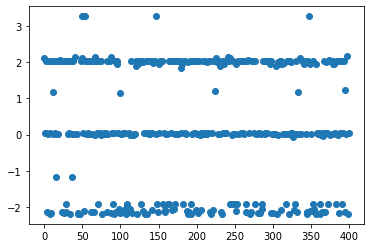

In [18]:
M = np.arange(400)
plt.scatter(M,lst1[10])

In [19]:
ACC1 = np.array(ACC1)#训练集的分别正确率
ACC2 = np.array(ACC2)
ACC_final = np.array(ACC_final)#训练集的总正确率
ACC_pre = np.array(ACC_pre)#预测集的总准确率
RI1 = np.array(RI1)
RI2 = np.array(RI2)
ACCp2 = np.array(ACCp2)
ACCp1 = np.array(ACCp1)#预测集的分别准确率
print(ACC1.mean())
print(ACC2.mean())
print(ACC_final.mean())

print(ACCp1.mean())
print(ACCp2.mean())
print(ACC_pre.mean())

0.9547500000000001
0.9722500000000001
0.937375
0.9577499999999999
0.97
0.9377500000000001


In [20]:
Deviation_00 = np.array(Deviation_0)
Deviation_11 = np.array(Deviation_1)
Deviation_22 = np.array(Deviation_2)
Deviation1_1 = np.array(Deviation1_1)
Deviation1_2 = np.array(Deviation1_2)
Deviation1_3 = np.array(Deviation1_3)
Deviation2_1 = np.array(Deviation2_1)
Deviation2_2 = np.array(Deviation2_2)
Deviation2_3 = np.array(Deviation2_3)
RI1 = np.array(RI1)
RI2 = np.array(RI2)
print(Deviation_00.mean())
print(Deviation_11.mean())
print(Deviation_22.mean())
print(Deviation1_1.mean())
print(Deviation1_2.mean())
print(Deviation1_3.mean())
print(Deviation2_1.mean())
print(Deviation2_2.mean())
print(Deviation2_3.mean())
print(RI1.mean())
print(RI2.mean())

-0.015537525253185663
0.0011177286173176093
-0.006662663092511306
0.010234604628903455
-0.0008033370539679459
0.0020379120715583897
-5.413024646570008e-05
0.007846659607591417
0.008995456508587707
0.9626058897243108
0.9516453634085213


In [25]:
result_need = []
result_need.append(K1)
result_need.append(K2)
result_need.append(RI1)
result_need.append(RI2)
result_need.append(beta0_all)
result_need.append(beta1_all)
result_need.append(beta2_all)
result_need.append(alpha1_1all)
result_need.append(alpha1_2all)
result_need.append(alpha1_3all)
result_need.append(alpha2_1all)
result_need.append(alpha2_2all)
result_need.append(alpha2_3all)
result_need.append(beta0_allor)
result_need.append(beta1_allor)
result_need.append(beta2_allor)
result_need.append(alpha1_1allor)
result_need.append(alpha1_2allor)
result_need.append(alpha1_3allor)
result_need.append(alpha2_1allor)
result_need.append(alpha2_2allor)
result_need.append(alpha2_3allor)
result_need.append(ACC1)
result_need.append(ACCp1)
result_need.append(ACC2)
result_need.append(ACCp2)
result_need.append(ACC_final)
result_need.append(ACC_pre)

result_need = np.array(result_need)
result_need = result_need.T
result_need = np.array(result_need)
save_need3 = pd.DataFrame(result_need,columns = ['K1','K2','RI1','RI2','beta_0','beta_1','beta_2','alpha1_1','alpha1_2','alpha1_3','alpha2_1','alpha2_2','alpha2_3','beta_0^{or}','beta_1^{or}','beta_2^{or}','alpha1_1^{or}','alpha1_2^{or}','alpha1_3^{or}','alpha2_1^{or}','alpha2_2^{or}','alpha2_3^{or}','ACC1','ACCp1','ACC2','ACCp2','ACC_final','ACC_pre']) 
#save_need = pd.DataFrame(result_need,columns = ['K1','K2','RI_1','RI_2','beta_0','beta_1','beta_2','alpha1_1','alpha1_2','alpha2_1','alpha2_2','beta_0^{or}','beta_1','beta_2','alpha1_1','alpha1_2','alpha2_1','alpha2_2','a11','a21']) 
save_need3.to_csv('XGDP 4.4 first with n = 400.csv',index=False,header=True) 

In [81]:
K1

array([3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3])

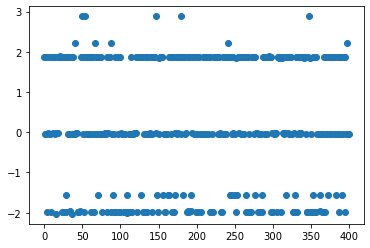

In [82]:
M = np.arange(400)
plt.scatter(M,lst1[10])

In [83]:
save_need3

,K1,K2,RI1,RI2,beta_0,beta_1,beta_2,alpha1_1,alpha1_2,alpha1_3,...,alpha1_3^{or},alpha2_1^{or},alpha2_2^{or},alpha2_3^{or},ACC1,ACCp1,ACC2,ACCp2,ACC_final,ACC_pre
0,3.0,3.0,0.954737,0.935025,1.000777,1.044312,1.050186,-1.971603,-0.063015,2.034643,...,2.027560,-1.479591,0.445295,2.476445,0.9550,0.975,0.9575,0.985,0.9275,0.965
1,3.0,3.0,0.917769,0.931291,0.959876,0.969881,1.032515,-1.760104,-0.178564,2.037173,...,2.022051,-1.458058,0.501597,2.484774,0.9475,0.925,0.9525,0.950,0.9100,0.875
2,3.0,3.0,0.896216,0.944085,1.123834,0.973063,1.024365,-2.124546,-0.125244,2.044892,...,2.057233,-1.662022,0.373784,2.434519,0.9575,0.895,0.9475,0.955,0.9075,0.855
3,3.0,3.0,0.959875,0.970702,0.972714,1.008480,1.024024,-2.068133,0.085135,2.014895,...,2.039656,-1.381605,0.473843,2.477594,0.9550,0.970,0.9725,0.970,0.9350,0.955
4,3.0,3.0,0.878246,0.975414,1.022646,0.987022,1.033093,-2.109594,0.130048,1.933248,...,2.017312,-1.413218,0.548551,2.465379,0.9475,0.900,0.9650,0.965,0.9175,0.865
5,3.0,3.0,0.920476,0.959712,1.003510,1.011744,0.964191,-2.101772,-0.185617,1.901374,...,1.953100,-1.503012,0.532718,2.417545,0.9750,0.940,0.9625,0.930,0.9400,0.870
6,3.0,3.0,0.961303,0.973559,1.053210,0.949122,1.024429,-2.104432,-0.071898,1.932337,...,1.955810,-1.470675,0.580833,2.489311,0.9750,0.955,0.9800,0.970,0.9575,0.940
7,3.0,3.0,0.896216,0.974160,1.072820,0.966075,0.941928,-2.151372,-0.056172,1.840065,...,2.021379,-1.518125,0.485319,2.488686,0.9675,0.895,0.9625,0.945,0.9350,0.850
8,3.0,3.0,0.953133,0.938584,0.980626,0.987528,1.044524,-1.795470,-0.054669,2.075302,...,2.058078,-1.607439,0.480368,2.400494,0.9875,0.930,0.9425,0.935,0.9400,0.880
9,3.0,3.0,0.913296,0.938020,0.854156,1.031926,0.965309,-1.849978,0.052159,2.093794,...,1.979432,-1.325938,0.553977,2.562384,0.9500,0.955,0.9425,0.895,0.9025,0.860


In [26]:
pre1 = pd.DataFrame(Pre1)
pre1.to_csv('XGDP 4.4 first with n = 400 pre1.csv',index=False,header=True)

pre2 = pd.DataFrame(Pre2)
pre2.to_csv('XGDP 4.4 first with n = 400 pre2.csv',index=False,header=True)

In [21]:
#系数beta0的方差
print("beta0_all的总体标准差:", np.std(beta0_all))
print("beta_0的样本标准差:", np.std(beta0_all, ddof=1))
print("beta1_all的总体标准差:", np.std(beta1_all))
print("beta_1的样本标准差:", np.std(beta1_all, ddof=1))
print("beta2_all的总体标准差:", np.std(beta2_all))
print("beta_2的样本标准差:", np.std(beta2_all, ddof=1))
#系数alpha1的方差
alpha1_1all= np.array(alpha1_1all)
alpha1_2all = np.array(alpha1_2all)
alpha1_3all = np.array(alpha1_3all)
print("alpha11_1的总体标准差:", np.std(alpha1_1all))
print("alpha11_1的样本标准差:", np.std(alpha1_1all, ddof=1))
print("alpha11_2的总体标准差:", np.std(alpha1_2all))
print("alpha11_2的样本标准差:", np.std(alpha1_2all, ddof=1))
print("alpha11_3的总体标准差:", np.std(alpha1_3all))
print("alpha11_3的样本标准差:", np.std(alpha1_3all, ddof=1))
#系数beta2的方差
alpha2_1all= np.array(alpha2_1all)
alpha2_2all = np.array(alpha2_2all)
alpha2_3all = np.array(alpha2_3all)
print("alpha22_1的总体标准差:", np.std(alpha2_1all))
print("alpha22_1的样本标准差:", np.std(alpha2_1all, ddof=1))
print("alpha22_2的总体标准差:", np.std(alpha2_2all))
print("alpha22_2的样本标准差:", np.std(alpha2_2all, ddof=1))
print("alpha22_3的总体标准差:", np.std(alpha2_3all))
print("alpha22_3的样本标准差:", np.std(alpha2_3all, ddof=1))

beta0_all的总体标准差: 0.07841682951825564
beta_0的样本标准差: 0.0804539695248824
beta1_all的总体标准差: 0.025630566641784338
beta_1的样本标准差: 0.026296406526146617
beta2_all的总体标准差: 0.034631968035743074
beta_2的样本标准差: 0.03553164949477741
alpha11_1的总体标准差: 0.05621609684019367
alpha11_1的样本标准差: 0.05767649839676134
alpha11_2的总体标准差: 0.05019857148060522
alpha11_2的样本标准差: 0.05150264764470015
alpha11_3的总体标准差: 0.04612760037560091
alpha11_3的样本标准差: 0.047325919419001564
alpha22_1的总体标准差: 0.05029844654315144
alpha22_1的样本标准差: 0.051605117296785734
alpha22_2的总体标准差: 0.043633960994208576
alpha22_2的样本标准差: 0.044767499395786
alpha22_3的总体标准差: 0.04581949613543811
alpha22_3的样本标准差: 0.04700981113840889


In [22]:
print(Deviation_00.mean()/np.std(beta0_all,ddof=1))#beta0的偏差与方差比
print(Deviation_11.mean()/np.std(beta1_all,ddof=1))#beta0的偏差与方差比
print(Deviation_22.mean()/np.std(beta2_all,ddof=1))#beta0的偏差与方差比
print(Deviation1_1.mean()/np.std(alpha1_1all,ddof=1))#beta1第一段偏差和方差的比
print(Deviation1_2.mean()/np.std(alpha1_2all,ddof=1))#beta1第一段偏差和方差的比
print(Deviation1_3.mean()/np.std(alpha1_3all,ddof=1))
print(Deviation2_1.mean()/np.std(alpha2_1all,ddof=1))#beta2第一段偏差和方差的比
print(Deviation2_2.mean()/np.std(alpha2_2all,ddof=1))#beta2第一段偏差和方差的比
print(Deviation2_3.mean()/np.std(alpha2_3all,ddof=1))

-0.1931231652700529
0.0425049945971229
-0.18751347565472895
0.17744843937124571
-0.015597975846016778
0.04306122515054951
-0.0010489317591197806
0.1752758075276822
0.19135274724041726


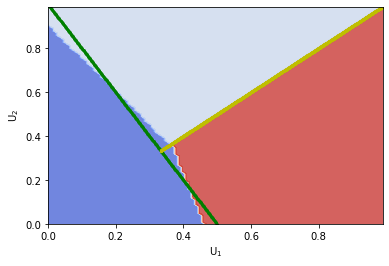

In [13]:
Pre1 = mat(pre1).A
from collections import Counter
Pre_final1 = []
#进行投票，得到打的10000个点的最终预测，并将其可视化
for i in range(10000):
    fen1 = Pre1[:,i].reshape(1,-1)[0]
    fen_final1 = Counter(fen1).most_common()[0][0]
    Pre_final1.append(fen_final1)
Pre_final1 = np.array(Pre_final1).reshape(xx.shape)
plt.contourf(xx,yy,Pre_final1,cmap = plt.cm.coolwarm,alpha = 0.8)
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
xx1 = np.arange(0,0.5,0.001)
xx2 = []
for i in range(len(xx1)):
    x11 = xx1[i]
    xx22 = 1 - 2*x11
    xx2.append(xx22)
xx2 = np.array(xx2)
resu = []
resu.append(xx1)
resu.append(xx2)
resu = np.array(resu)
resu = resu.T
np.shape(resu)
xx1_1 = resu[:,0]
xx1_2 = resu[:,1]
plt.scatter(xx1_1,xx1_2,s = 3,marker='o', c='g')
yy1 = np.arange(1/3,1,0.001)
yy2 = []
for i in range(len(yy1)):
    y11 = yy1[i]
    yy22 = (y11)
    yy2.append(yy22)
yy2 = np.array(yy2)
resu2 = []
resu2.append(yy1)
resu2.append(yy2)
resu2 = np.array(resu2)
resu2 = resu2.T
np.shape(resu2)
yy1_1 = resu2[:,0]
yy1_2 = resu2[:,1]
img41 = plt.scatter(yy1_1,yy1_2,s = 5,marker='o',c='y') 
plt.xlabel('U$_1$',fontsize=10)
plt.ylabel('U$_2$',fontsize=10)
plt.savefig("img41.png")
plt.show()
#beta1通过投票的最终预测

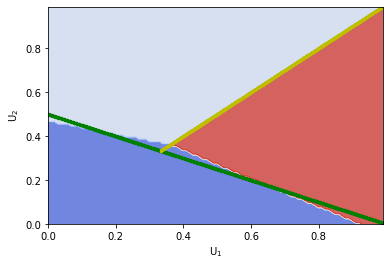

In [14]:
Pre2 = mat(pre2).A
from collections import Counter
Pre_final2 = []
#进行投票，得到打的40000个点的最终预测，并将其可视化
for i in range(10000):
    fen2 = Pre2[:,i].reshape(1,-1)[0]
    fen_final2 = Counter(fen2).most_common()[0][0]
    Pre_final2.append(fen_final2)
Pre_final2 = np.array(Pre_final2).reshape(xx.shape)
plt.contourf(xx,yy,Pre_final2,cmap = plt.cm.coolwarm,alpha = 0.8)
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())

xx1 = np.arange(0,1,0.001)
xx2 = []
for i in range(1000):
    x11 = xx1[i]
    xx22 = 1/2 - 0.5*x11
    xx2.append(xx22)
xx2 = np.array(xx2)
resu = []
resu.append(xx1)
resu.append(xx2)
resu = np.array(resu)
resu = resu.T
np.shape(resu)
xx1_1 = resu[:,0]
xx1_2 = resu[:,1]
plt.scatter(xx1_1,xx1_2,s = 5,marker='o', c='g')
yy1 = np.arange(1/3,1,0.001)
yy2 = []
for i in range(len(yy1)):
    y11 = yy1[i]
    yy22 = y11
    yy2.append(yy22)
yy2 = np.array(yy2)
resu2 = []
resu2.append(yy1)
resu2.append(yy2)
resu2 = np.array(resu2)
resu2 = resu2.T
np.shape(resu2)
yy1_1 = resu2[:,0]
yy1_2 = resu2[:,1]
img42 = plt.scatter(yy1_1,yy1_2,s = 5,marker='o',c='y') 
plt.xlabel('U$_1$',fontsize=10)
plt.ylabel('U$_2$',fontsize=10)
plt.savefig("img42.png")
plt.show()
#beta2通过投票的最终